In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import DBSCAN

can_log_path='logs/9_2016 Toyota Yaris/driving/9_driving_CAN_continuous.log'

# The CAN log format: (timestamp) can0 ID#Payload
df_can = pd.read_csv(can_log_path, sep='\s+', header=None, names=['timestamp', 'bus', 'raw_frame'])

# Split the raw_frame into ID and Payload
frame_parts = df_can['raw_frame'].str.split('#', expand=True)
df_can['id'] = frame_parts[0]
df_can['payload'] = frame_parts[1]

# remove brackets from timestamp 
df_can['timestamp'] = df_can['timestamp'].str.strip('()').astype(float).astype(int)

print(df_can.shape,df_can.head())

print(hex(int(180)))

(876076, 5)     timestamp   bus             raw_frame   id           payload
0  1719648554  can0  0AA#25FD260125F625F4  0AA  25FD260125F625F4
1  1719648554  can0      1AA#0000000000B1  1AA      0000000000B1
2  1719648554  can0  260#00000000000062CC  260  00000000000062CC
3  1719648554  can0  442#4302000003000000  442  4302000003000000
4  1719648554  can0  680#D800010000000000  680  D800010000000000
0xb4


In [4]:
def find_likely_counters(df, top_n=5):
    """Scans top IDs to see if any byte increments like a counter (0,1,2,3...)."""
    print("\n--- Scanning for Counters ---")
    # Only check the most frequent IDs to save time
    top_ids = df['id'].value_counts().head(top_n).index
    
    for can_id in top_ids:
        group = df[df['id'] == can_id]
        payloads = group['payload'].tolist()
        
        # Quick check: Look at the last byte (common location for counters)
        # Convert last 2 chars of hex to int
        last_bytes = [int(p[-2:], 16) for p in payloads[:100]] # Check first 100 frames
        
        # Check for simple incrementing pattern (mod 16 for 4-bit counters)
        score = 0
        for i in range(len(last_bytes)-1):
            if (last_bytes[i] + 1) % 16 == last_bytes[i+1] % 16: # 4-bit counter check
                score += 1
                
        if score > 50: # If >50% of frames increment correctly
            print(f"ID {can_id} looks like a COUNTER! (Last byte analysis)")

# Run the scanner
find_likely_counters(df_can)


--- Scanning for Counters ---


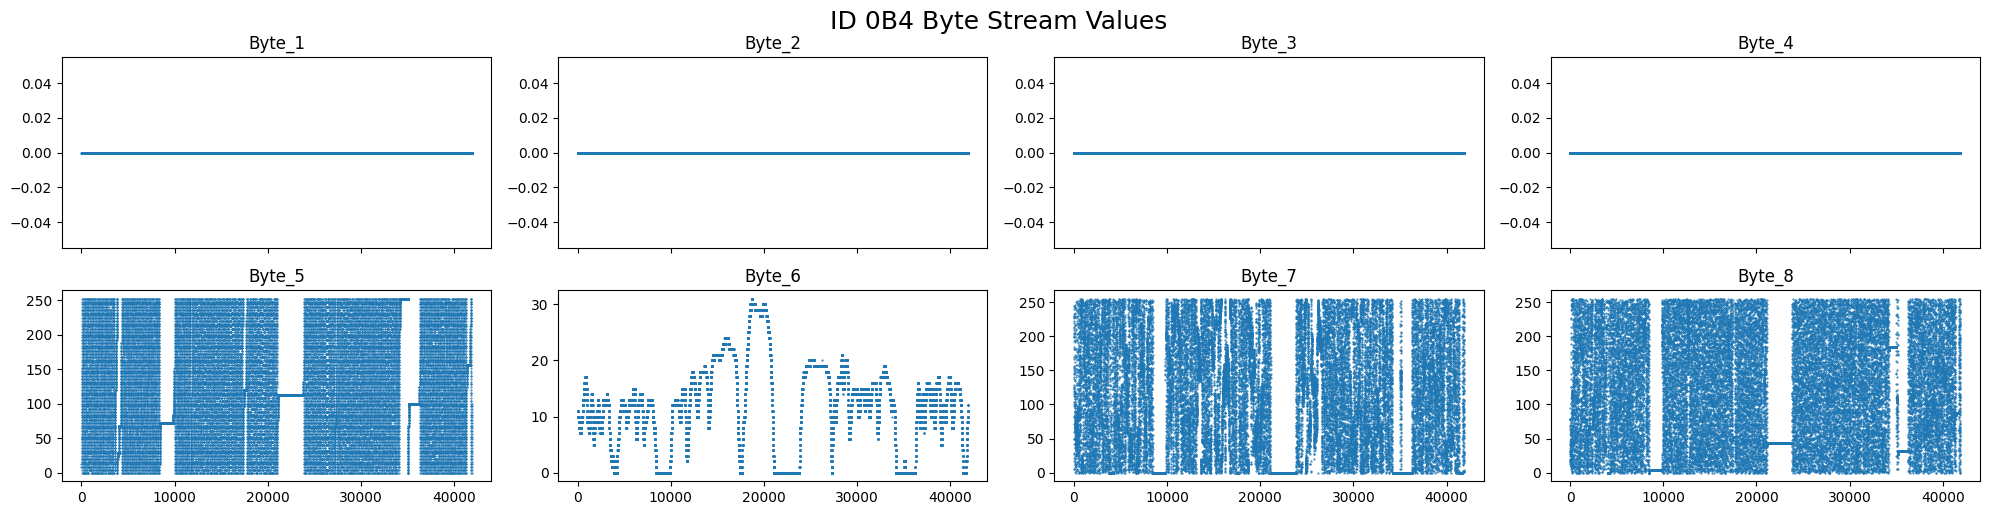

In [2]:
target_id = '0B4'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    # payload_int = int(hex_str[:16], 16)
    byte_array=[int(hex_str[i:i+2],16) for i in range(0,len(hex_str),2)]
    X_list.append(byte_array)
    while len(byte_array) < 8:
        byte_array.append(0)
byte_data = np.array(X_list)

df_bytes = pd.DataFrame(byte_data, columns=[f'Byte_{i+1}' for i in range(8)])
df_bytes.tail()
# Setup figure for plotting all 8 bytes
fig, axes = plt.subplots(2, 4, figsize=(20, 5), sharex=True)
axes = axes.flatten()

# Loop through each byte stream and plot the raw integer value
for byte_index, byte_name in enumerate(df_bytes.columns):
    byte_stream = df_bytes[byte_name].values
    
    ax = axes[byte_index]
    
    # Plot the raw integer value over the chronological frame index
    ax.plot(byte_stream, marker='.', linestyle='-', markersize=1, linewidth=0)
    
    # Set Y-axis to the full possible range for clear comparison
    # ax.set_ylim(-5, 260) 
    ax.set_title(f"{byte_name}")

plt.tight_layout()
plt.suptitle(f" ID {target_id} Byte Stream Values", y=1.02, fontsize=18)
plt.show()

In [3]:
target_id = '0B3'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
X_list = []

prev_hex=hex(0)

for i,hex_str in enumerate(all_payloads_hex):
    # payload_int = int(hex_str[:16], 16)
    byte_array=[int(hex_str[i:i+2],16) for i in range(0,len(hex_str),2)]
    X_list.append(byte_array)
    while len(byte_array) < 8:
        byte_array.append(0)
byte_data = np.array(X_list)

df_bytes = pd.DataFrame(byte_data, columns=[f'Byte_{i+1}' for i in range(8)])
df_bytes.tail()
# Setup figure for plotting all 8 bytes
fig, axes = plt.subplots(2, 4, figsize=(20, 5), sharex=True)
axes = axes.flatten()

# Loop through each byte stream and plot the raw integer value
for byte_index, byte_name in enumerate(df_bytes.columns):
    byte_stream = df_bytes[byte_name].values
    
    ax = axes[byte_index]
    
    # Plot the raw integer value over the chronological frame index
    ax.plot(byte_stream, marker='.', linestyle='-', markersize=1, linewidth=0)
    
    # Set Y-axis to the full possible range for clear comparison
    # ax.set_ylim(-5, 260) 
    ax.set_title(f"{byte_name}")

plt.tight_layout()
plt.suptitle(f" ID {target_id} Byte Stream Values", y=1.02, fontsize=18)
plt.show()

ValueError: Shape of passed values is (0, 1), indices imply (0, 8)

In [3]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt 

gps_log_path='logs/9_2016 Toyota Yaris/driving/9_driving_GPS.log'

# The GPS log
df_gps = pd.read_csv(gps_log_path, sep=',', header=None, names=['timestamp', 'lat', 'long', 'alt'])

print(df_gps.head())

      timestamp        lat        long   alt
0  1.719648e+09 -38.014699  145.315803  78.2
1  1.719648e+09 -38.014699  145.315804  78.1
2  1.719648e+09 -38.014698  145.315804  77.9
3  1.719648e+09 -38.014699  145.315803  77.8
4  1.719648e+09 -38.014699  145.315803  77.7


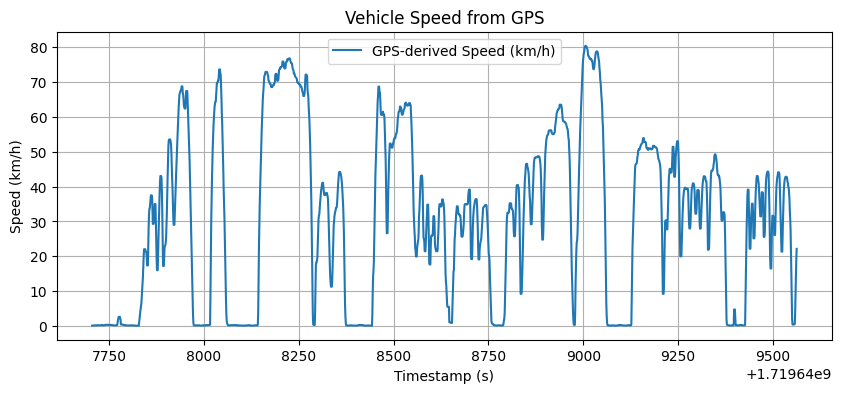

In [4]:
# Haversine formula
R = 6371000.0  # Earth radius in meters

df_gps['timestamp'] = pd.to_numeric(df_gps['timestamp'], errors='coerce')

df_gps=df_gps[df_gps['timestamp']<1719649564]
# df_gps=df_gps[df_gps['timestamp']>1719648554]

def haversine(lat1, lon1, lat2, lon2):
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = phi2 - phi1
    dlmb = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlmb/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Compute distance and time delta
lat1 = df_gps['lat']
lon1 = df_gps['long']
lat2 = df_gps['lat'].shift(-1)
lon2 = df_gps['long'].shift(-1)
dt = df_gps['timestamp'].shift(-1) - df_gps['timestamp']

df_gps['dist_m'] = haversine(lat1, lon1, lat2, lon2)
df_gps['speed_mps'] = df_gps['dist_m'] / dt
df_gps['speed_kmh'] = df_gps['speed_mps'] * 3.6

# Clean and smooth
df_gps = df_gps.dropna(subset=['speed_kmh'])
df_gps['speed_kmh'] = df_gps['speed_kmh'].rolling(window=5, center=True, min_periods=1).median()

# Plot
plt.figure(figsize=(10, 4))
plt.plot(df_gps['timestamp'], df_gps['speed_kmh'], label='GPS-derived Speed (km/h)')
plt.xlabel('Timestamp (s)')
plt.ylabel('Speed (km/h)')
plt.title('Vehicle Speed from GPS')
plt.grid(True)
plt.legend()
plt.show()

1719649564
1719648554


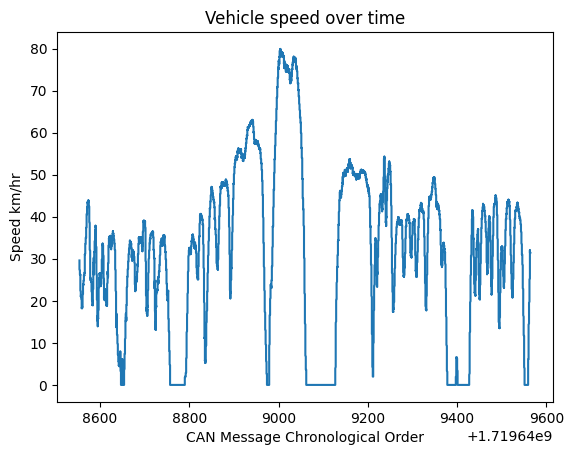

In [5]:
target_id = '0B4'
all_payloads_hex = df_can[df_can['id'] == target_id]['payload'].tolist()
all_payloads_timestamps = df_can[df_can['id'] == target_id]['timestamp'].tolist()
speeds=[]
        
for i, payload_hex in enumerate(all_payloads_hex):
    # Extract Byte_6 and Byte_7 (little endian)
    byte6 = payload_hex[10:12]
    byte7 = payload_hex[12:14]
    raw = int(byte6+byte7, 16)  # little endian: high + low
    speed = raw * 0.01  # assuming DBC scaling (0.01, 0)
    speeds.append(speed)

plt.plot(all_payloads_timestamps,speeds)
plt.title('Vehicle speed over time')
plt.xlabel('CAN Message Chronological Order')
plt.ylabel('Speed km/hr')

print(all_payloads_timestamps[-1])
print(all_payloads_timestamps[0])

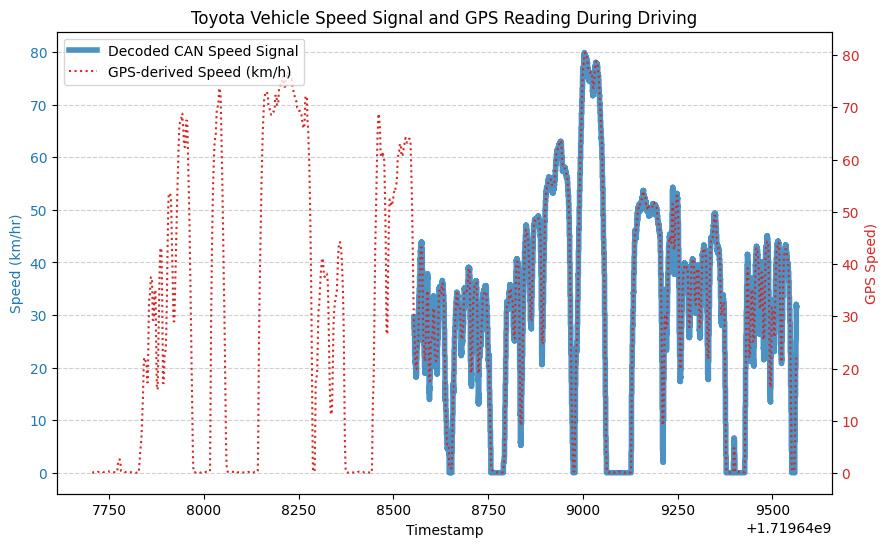

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Speed on the primary axis (ax1)
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Speed (km/hr)', color=color)
ax1.plot(all_payloads_timestamps,speeds, color=color, label='Decoded CAN Speed Signal', linewidth=4,alpha=0.8)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, axis='y', linestyle='--', alpha=0.6)

# Create a secondary axis (ax2) that shares the same x-axis
ax2 = ax1.twinx()

color = 'tab:red'
ax2.set_ylabel('GPS Speed)', color=color)
ax2.plot(df_gps['timestamp'], df_gps['speed_kmh'],color=color, label='GPS-derived Speed (km/h)', linestyle=':', alpha=1)
ax2.tick_params(axis='y', labelcolor=color)


# Add a title
plt.title('Toyota Vehicle Speed Signal and GPS Reading During Driving')

# Add a combined legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')